In [31]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl 
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder


In [32]:
# Bypass SSL verification for macOS
ssl._create_default_https_context = ssl._create_unverified_context

# Set visualization style for professional looking plots
sns.set_theme(style="whitegrid")

# 2. Dataset Collection (Loading the data from a stable mirror)
url = "https://raw.githubusercontent.com/patilgirish815/Kidney_Cancer_Prediction_Using_Machine_Learning/main/dataset/kidney_disease.csv"


# Some datasets use '\t?' as well as '?' for missing values
df = pd.read_csv(url, na_values=['?', '\t?'])

In [33]:
df.head()  # Display the first few rows of the dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [34]:
# Drop the 'id' column if it exists, as it has no clinical/predictive value
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# 3. Rename columns for better readability
columns_mapping = {
    'bp': 'blood_pressure', 'sg': 'specific_gravity', 'al': 'albumin', 'su': 'sugar',
    'rbc': 'red_blood_cells', 'pc': 'pus_cell', 'pcc': 'pus_cell_clumps', 'ba': 'bacteria',
    'bgr': 'blood_glucose_random', 'bu': 'blood_urea', 'sc': 'serum_creatinine', 
    'sod': 'sodium', 'pot': 'potassium', 'hemo': 'hemoglobin', 'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count', 'rc': 'red_blood_cell_count', 'htn': 'hypertension',
    'dm': 'diabetes_mellitus', 'cad': 'coronary_artery_disease', 'appet': 'appetite',
    'pe': 'pedal_edema', 'ane': 'anemia', 'classification': 'target' # Updated mapping
}
df.rename(columns=columns_mapping, inplace=True)
# print(df.head())

# Clean target variable (removing any invisible tabs/spaces)
df['target'] = df['target'].str.strip()
df['target'] = df['target'].map({'ckd': 1, 'notckd': 0}) 

In [35]:
df.head()  # Display the first few rows of the dataset for verification column renaming and target cleaning

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [36]:
# 4. Basic Inspection
print("Dataset Shape:", df.shape)
print("\n--- Data Types & Missing Values ---")
print(df.info())

Dataset Shape: (400, 25)

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    str    
 6   pus_cell                 335 non-null    str    
 7   pus_cell_clumps          396 non-null    str    
 8   bacteria                 396 non-null    str    
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 

In [37]:
print("Null value counts:\n", df.isnull().sum())


Null value counts:
 age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
target                       0
dtype: int64


In [38]:
print("Cross-tabulation of target variable:\n", df['target'].value_counts())

Cross-tabulation of target variable:
 target
1    250
0    150
Name: count, dtype: int64


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_92620/948061288.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])


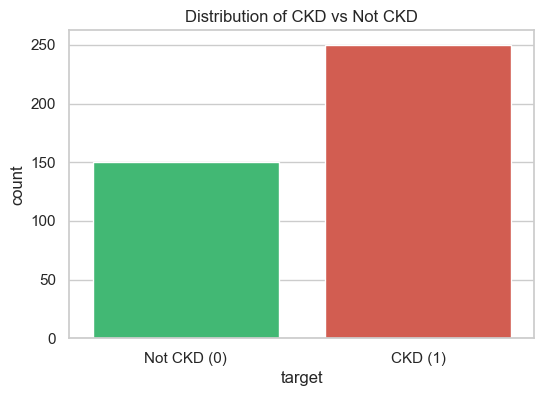

In [39]:
# 5. Visualizing the Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])
plt.title("Distribution of CKD vs Not CKD")
plt.xticks(ticks=[0, 1], labels=['Not CKD (0)', 'CKD (1)'])
plt.show()

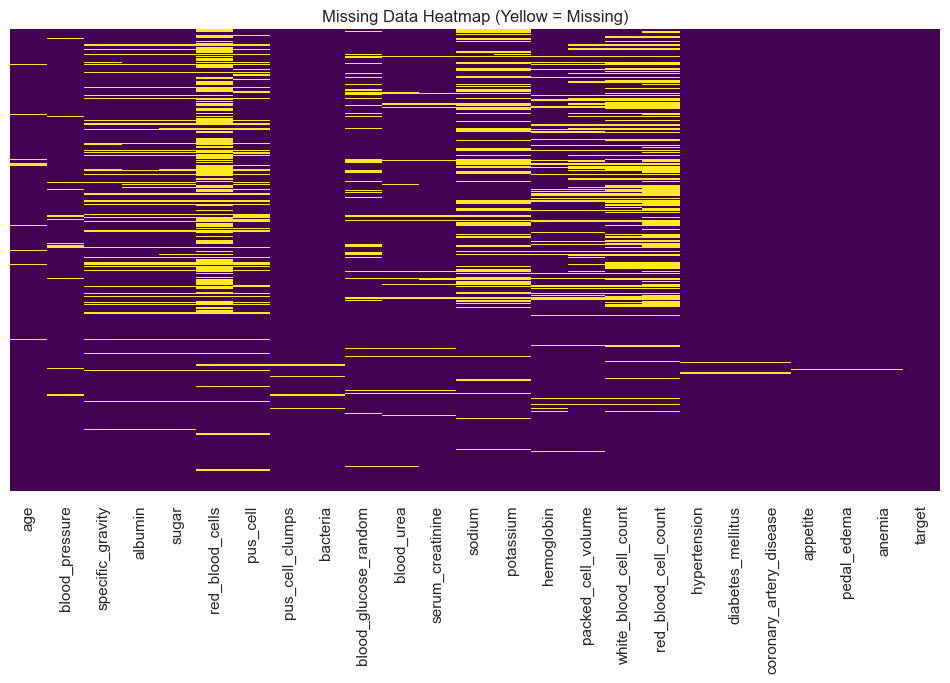

In [40]:
# 6. Visualizing Missing Data Patterns
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.show()

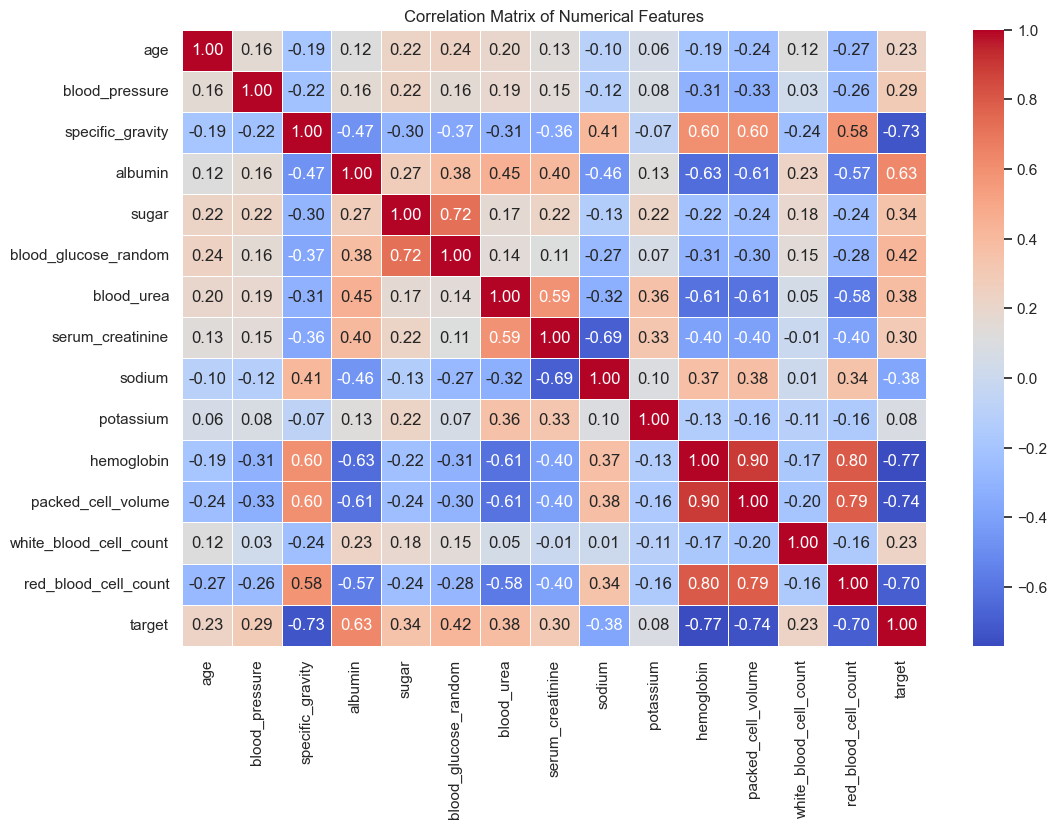

In [41]:
# 7. Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [42]:
print("Starting Data Cleaning...")

# 1. Clean invisible typos (tabs and spaces) in categorical columns
# The dataset has hidden strings like '\tyes', ' yes', or '\tno'
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # Convert to string, strip whitespace and tabs, then replace 'nan' back to actual np.nan
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

Starting Data Cleaning...


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_92620/2593296508.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [43]:
df.head()  # Display the first few rows of the dataset

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [45]:
# 2. Fix Incorrect Data Types
# These columns are numerical but got parsed as objects due to typos in the raw file
cols_to_numeric = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
for col in cols_to_numeric:
    # errors='coerce' forces any unreadable text (like '?') to become NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [70]:
df.skew()# Check skewness of numerical features to understand distribution


age                        -0.649866
blood_pressure              1.618156
specific_gravity           -0.066714
albumin                     0.948510
sugar                       2.467775
red_blood_cells            -2.384616
pus_cell                   -1.586375
pus_cell_clumps             2.586749
bacteria                    3.918557
blood_glucose_random        1.973064
blood_urea                  2.651957
serum_creatinine            7.613471
sodium                     -7.704254
potassium                  13.059877
hemoglobin                 -0.378725
packed_cell_volume         -0.462337
white_blood_cell_count      1.692877
red_blood_cell_count       -0.185586
hypertension                0.551722
diabetes_mellitus           0.666294
coronary_artery_disease     2.987387
appetite                    1.466982
pedal_edema                 1.586375
anemia                      1.967779
target                     -0.518344
dtype: float64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'blood_pressure'}>,
        <Axes: title={'center': 'specific_gravity'}>,
        <Axes: title={'center': 'albumin'}>,
        <Axes: title={'center': 'sugar'}>],
       [<Axes: title={'center': 'red_blood_cells'}>,
        <Axes: title={'center': 'pus_cell'}>,
        <Axes: title={'center': 'pus_cell_clumps'}>,
        <Axes: title={'center': 'bacteria'}>,
        <Axes: title={'center': 'blood_glucose_random'}>],
       [<Axes: title={'center': 'blood_urea'}>,
        <Axes: title={'center': 'serum_creatinine'}>,
        <Axes: title={'center': 'sodium'}>,
        <Axes: title={'center': 'potassium'}>,
        <Axes: title={'center': 'hemoglobin'}>],
       [<Axes: title={'center': 'packed_cell_volume'}>,
        <Axes: title={'center': 'white_blood_cell_count'}>,
        <Axes: title={'center': 'red_blood_cell_count'}>,
        <Axes: title={'center': 'hypertension'}>,
        <Axes: title={'center': 'diabetes

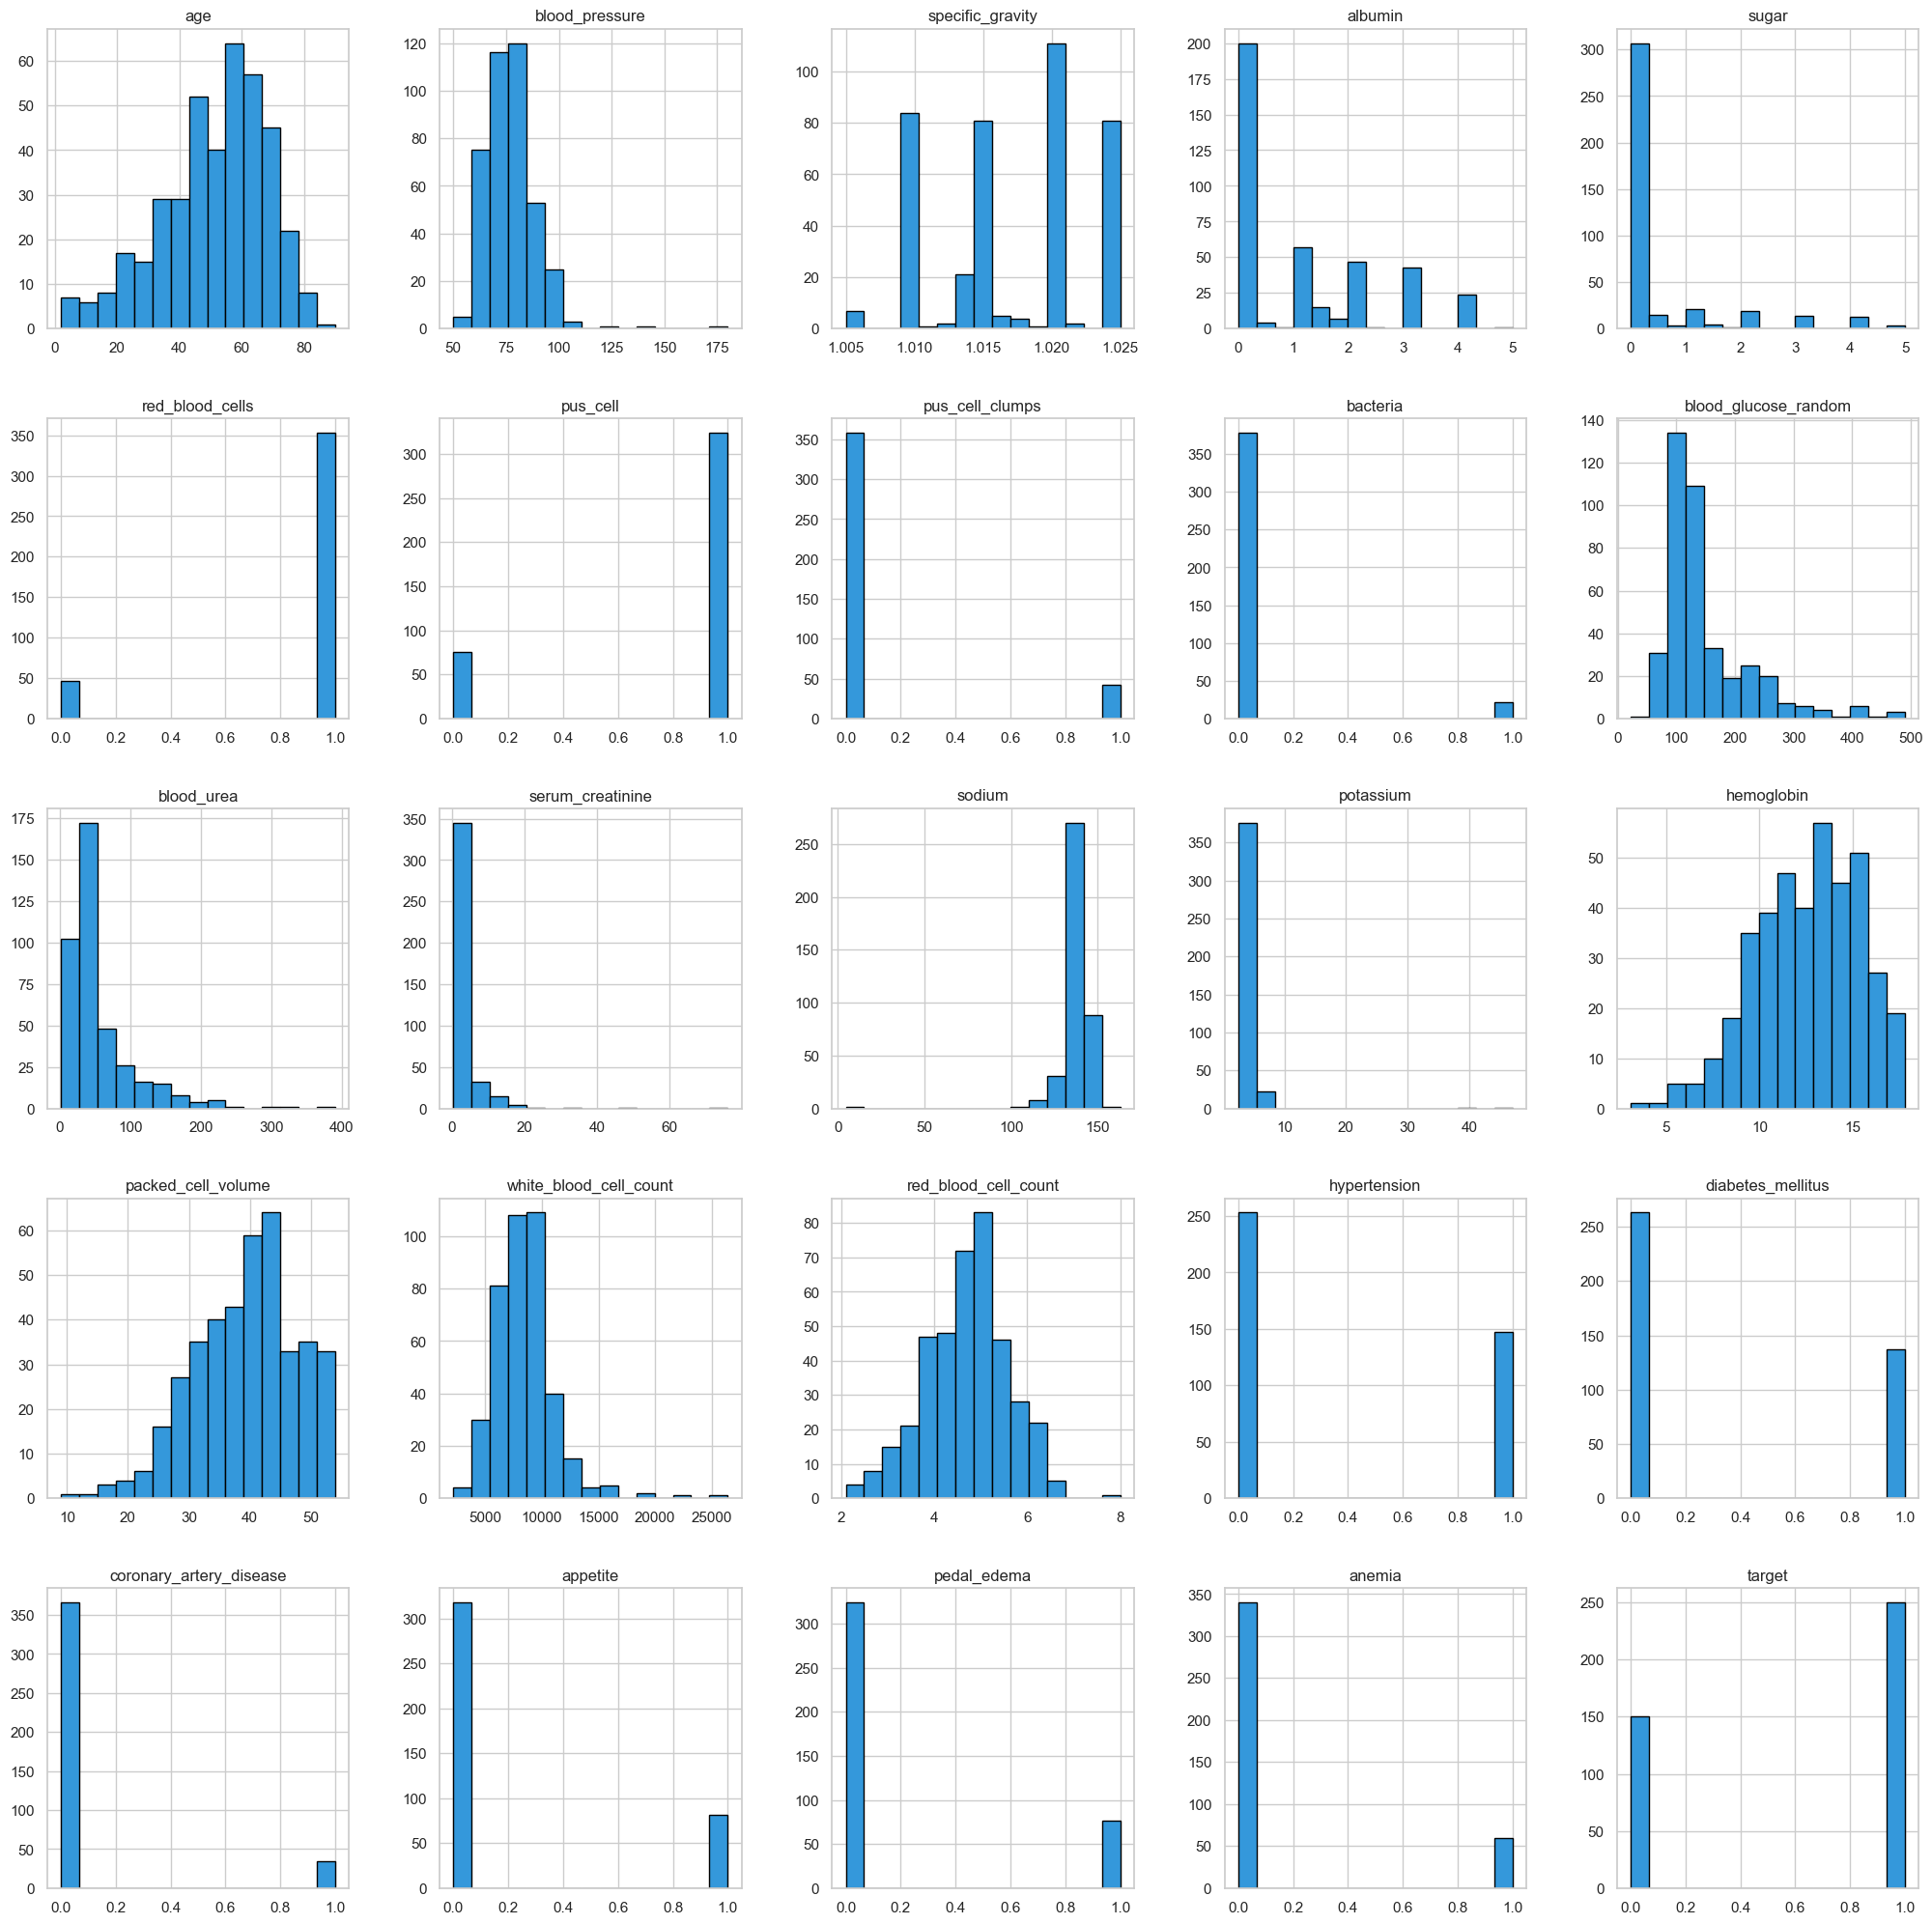

In [77]:
df.hist(bins=15, figsize=(25, 25), layout=(5, 5), color='#3498db', edgecolor='black')

In [78]:
df.head()  # Display the first few rows of the dataset before handling missing values

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.20,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,113.0,...,38.0,6000.0,4.96,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,3.80,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.90,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.60,0,0,0,0,0,0,1


In [47]:
# 3. Handle Missing Values (Imputation)
# Update our lists of categorical and numerical columns after the dtype fix
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Do NOT impute the target variable! Drop it from the numerical list temporarily.
if 'target' in numerical_cols:
    numerical_cols = numerical_cols.drop('target')

# A. Categorical Imputation: Fill missing with Mode (most frequent value)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# B. Numerical Imputation: Use KNN Imputer (Research-level)
print("Applying KNN Imputation for numerical features...")
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])

Applying KNN Imputation for numerical features...


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_92620/2723300367.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [48]:
# 4. Encode Categorical Variables (Label Encoding)
# Machine Learning models need numbers, not text like 'normal' or 'abnormal'
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le # We save the encoder for deployment later!

In [54]:
# 5. Final Sanity Check
print("\n--- Data Types After Cleaning ---")
print(df.info())
print("\n--- Total Missing Values After Cleaning ---")
print(df.isnull().sum().sum()) # Should print 0


--- Data Types After Cleaning ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    int64  
 6   pus_cell                 400 non-null    int64  
 7   pus_cell_clumps          400 non-null    int64  
 8   bacteria                 400 non-null    int64  
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  he